In [ ]:
import xarray as xr
import numpy as np
import pandas as pd
from geostat_isoscapes_tools import sisal_utils
import seaborn as sns 
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
sns.set_style('darkgrid')

Temperature data is from [Mario Krapp's database](https://osf.io/8n43x/) and is associated to [this paper](https://www.nature.com/articles/s41597-021-01009-3#Abs1)

In [2]:
fn = '../data/temperature/temp_800ka_ann.nc'

with xr.open_dataset(filename_or_obj=fn, engine='netcdf4',decode_times=False) as file:
    print(file)
    # We need the data array containing variable d180p
    temp = file.temp

<xarray.Dataset> Size: 829MB
Dimensions:  (time: 800, lat: 360, lon: 720)
Coordinates:
  * time     (time) float64 6kB -7.99e+05 -7.98e+05 -7.97e+05 ... -1e+03 0.0
  * lon      (lon) float32 3kB -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
  * lat      (lat) float32 1kB -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
Data variables:
    temp     (time, lat, lon) float32 829MB ...
Attributes:
    CDI:           Climate Data Interface version 1.9.9 (https://mpimet.mpg.d...
    Conventions:   CF-1.6
    description:   Linear Regression Model reconstruction
    command_line:  src/data/reconstruct.py -l data/processed/hadcm3_000-120_a...
    history:       Mon Mar 01 09:40:14 2021: cdo -f nc4 -z zip_9 -L -s -add -...
    CDO:           Climate Data Operators version 1.9.9 (https://mpimet.mpg.d...


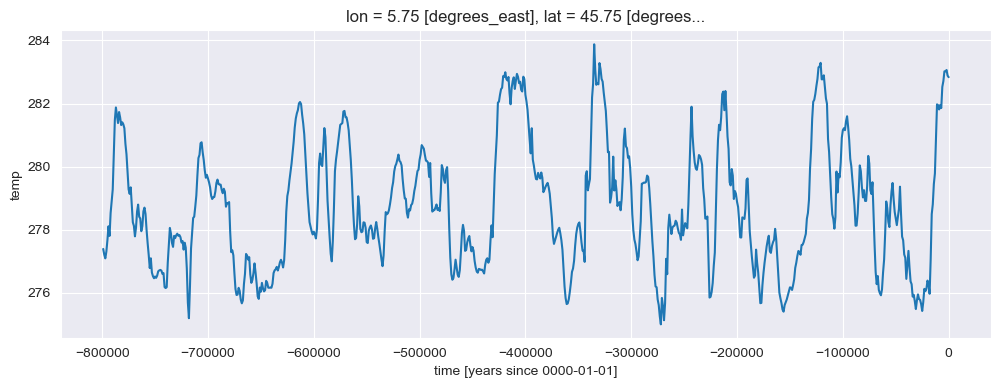

In [74]:
testloc_temp = temp.sel(lon=5.66,lat=45.96,method='nearest')
plt.figure(figsize=(12,4))
testloc_temp.plot()
plt.show()
# note that the time unit is incorrect : according to paper, it is in yrs BP and not from 0000-01-01 (if that even makes sense)

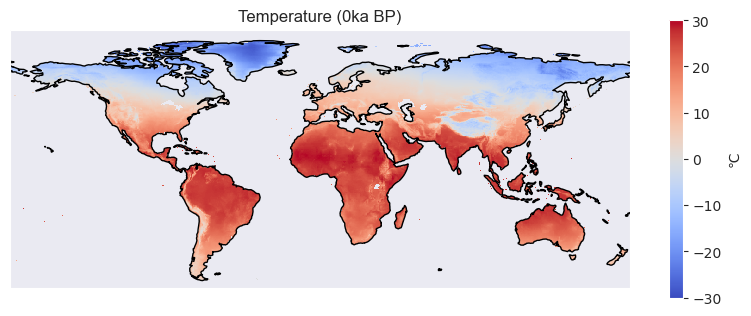

In [79]:
yearsBP = 0
data_crs = ccrs.PlateCarree()
proj = ccrs.PlateCarree()
x = temp.sel(time=-yearsBP).values 
lon = temp.coords['lon']
lat = temp.coords['lat']
fig, ax = plt.subplots(1,1,figsize=(10,4),subplot_kw={'projection':proj})
ax.add_feature(cfeature.COASTLINE,zorder=2)
ax.set_extent((-179.9,179.9,-60,90),crs=data_crs)

x -= 273.15
Norm = Normalize
vmin = -30.
vmax = 30.
units = u'\u2103'
variable = "Temperature"
cmap = mpl.colormaps['coolwarm']
plt.rcParams['font.family'] = 'DejaVu Sans'
im = ax.pcolormesh(lon,lat,x,norm=Norm(vmin,vmax),cmap=cmap,rasterized=True,transform=data_crs)
cbar = plt.colorbar(im,ax=ax,shrink=0.9,label=units)
ax.set_title(f"{variable} ({yearsBP//1000}ka BP)")
plt.show()

##### CONVERSION OF SPELEOTHEM DATA TO DRIP-WATER EQUIVALENTS

Conversion of the speleothems measurements from V-PDB standard units to drip-water equivalents in V-SMOW units, as in [Comas-Bru 2019](https://cp.copernicus.org/articles/15/1557/2019/)

We need a datframe with, at least, columns "sample_idx", "mineralogy", "age", "d18O","T".
1.  We will extract the 3 first columns + lon/lat coordinates in 2 extra columns
2.  We use the last 3 columns (location and age) to get T in the T dataset.


In [ ]:
# Load SISAL data
dict_sisal = sisal_utils.load_sisal()
sisal_chronology_df = dict_sisal['sisal_chronology']
site_df = dict_sisal['site']
entity_df = dict_sisal['entity']
d18O = dict_sisal['d18O']

# Get the valid samples indices (apply basic cleaning to remove superseded entities, exclude mixed mineralogy, samples without chronology...)
vsample_df,vchrono_df = sisal_utils.get_valid_sisal_samples_with_age(dict_sisal,chrono='lin_interp_age')
# Find the location for each sample : merge using the relations between tables (sample_id->entity_id->site_id)
entity_with_coords = entity_df.merge(site_df[['site_id', 'longitude','latitude']], on='site_id', how='left')
vsample_with_c = vsample_df.merge(entity_with_coords[['entity_id', 'longitude','latitude','site_id']], on='entity_id', how='left')
vsample_with_c_a = vsample_with_c.merge(vchrono_df[['sample_id','lin_interp_age']],on='sample_id',how='left')
data_to_convert = vsample_with_c_a.merge(d18O[['sample_id','d18O_measurement','d18O_precision']],on='sample_id',how='left')

# Retrieve closest T record from the T dataset. (TODO : interpolate instead of nearest val?)  
# OOM error
# data_to_convert['T'] = temp.sel(lon=xr.DataArray(data_to_convert['longitude'], dims="samples"),
#                                 lat=xr.DataArray(data_to_convert['latitude'] , dims="samples"),
#                                 method='nearest',
#                                ).values
# Slower but safer method :
def get_T(row)->float:
    val = temp.sel(lat = row['latitude'], lon = row['longitude'], time = -float(row['lin_interp_age']), method = 'nearest') # i do not take into account the elevation : to investigate bc possible impact on T?
    return float(val)

data_to_convert['T'] = data_to_convert.apply(get_T,axis=1)

Let us visualize the temperatures attributed to the sisal locations for a specified yearBP on top of the temperature dataset map.

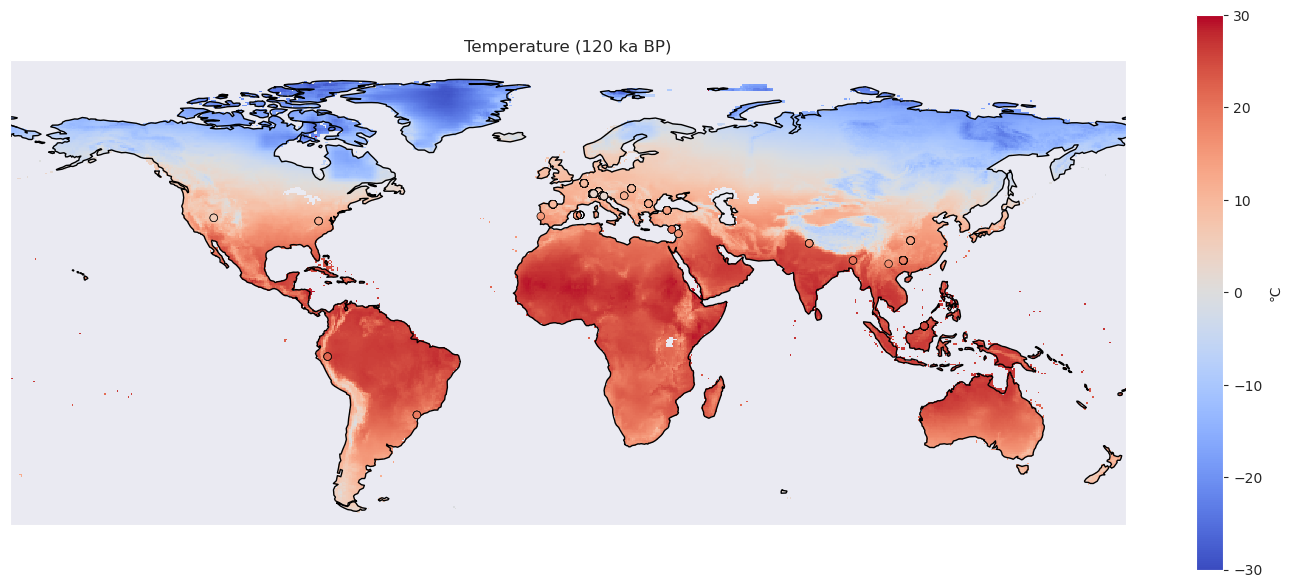

In [116]:
yearsBP  = 120000 # positive values only
sisal_width = 1000 # bin width in yr
data_crs = ccrs.PlateCarree()
proj     = ccrs.PlateCarree()

sisal_pts = data_to_convert.loc[ (data_to_convert['lin_interp_age']>=yearsBP)
                                &(data_to_convert['lin_interp_age']<yearsBP+sisal_width),
                                ['longitude','latitude','lin_interp_age','T']
                                ]

temp_to_plot   = temp.sel(time=-yearsBP).values 
lon = temp.coords['lon']
lat = temp.coords['lat']

fig, ax = plt.subplots(1, 1, figsize=(18, 8), subplot_kw={'projection': proj})
ax.add_feature(cfeature.COASTLINE, zorder=2)
ax.set_extent((-179.9, 179.9, -60, 90), crs=data_crs)

temp_to_plot -= 273.15 
vmin, vmax = -30., 30.
units = u'\u2103'
variable = "Temperature"
cmap = mpl.colormaps['coolwarm']
plt.rcParams['font.family'] = 'DejaVu Sans'

# Plot the xarray field
im = ax.pcolormesh(lon, lat, temp_to_plot, norm=Normalize(vmin, vmax),
                   cmap=cmap, rasterized=True, transform=data_crs)

# Plot the SISAL point data as scatter
sc = ax.scatter(
    sisal_pts['longitude'],
    sisal_pts['latitude'],
    c=sisal_pts['T']-273.15,
    s=30,              # marker size
    edgecolor='k',
    linewidth=0.5,
    cmap=cmap,
    norm=Normalize(vmin, vmax),
    transform=data_crs,
    zorder=3
)
cbar = plt.colorbar(im, ax=ax, shrink=0.9, label=units)
ax.set_title(f"{variable} ({yearsBP//1000} ka BP)")
plt.show()

We are now ready for the conversion of SISAL data.

In [120]:
conversion_cst = {'calcite'  :[16.1,24.6],
                      'aragonite':[18.34,31.954]
                      }
converted_data = data_to_convert.copy()
converted_data['d18Op_VSMOW']=np.nan

for mineralogy in ['calcite','aragonite']:
    mindata = converted_data.loc[converted_data['mineralogy']==mineralogy,['d18O_measurement','T']]
    converted_data.loc[converted_data['mineralogy']==mineralogy,'d18Op_VSMOW']= 1.03092*mindata['d18O_measurement']+30.92 - (conversion_cst[mineralogy][0]*1000/mindata['T'] - conversion_cst[mineralogy][1])